# pyLGS

> A Python package to model the atomic physics of laser guide stars

In [1]:
#| hide
from fastcore.test import test_close

In [2]:
#|hide
import plotly.io as pio
pio.renderers.default = "svg"

pyLGS performs simulations of the atomic physics of cw, modulated, and pulsed laser guide stars. The effects of the full atomic structure, atomic velocity distribution, one or multiple pump fields, the geomagnetic field, velocity-changing and spin-randomizing collisions, and atomic recoil are all taken into account.

## Installation

pyLGS uses the CVODE library from the [SUNDIALS package](https://computing.llnl.gov/projects/sundials), with [scikits.odes](https://scikits-odes.readthedocs.io/en/latest/installation.html) as the Python interface. Before installing pyLGS you may need to install SUNDIALS and the scikits.odes dependencies. On Ubuntu/Debian-based distributions (or on Windows using WSL) this can be done with `apt-get`:

```sh
sudo apt-get install python3-dev gcc gfortran libsundials-dev
```

(Note that SUNDIALS version 6 or later is required -- this is supplied by Ubuntu 24.04/Debian 12 and later.)

On macOS SUNDIALS can be installed using conda:

```sh
conda install conda-forge::sundials
```

(Note that homebrew also has a SUNDIALS package, but it doesn't install the header files that scikits.odes requires.)

Once the above dependencies are installed, pyLGS can be installed with `pip`:

```sh
pip install pylgs
```

## How to use

Import the package:

In [3]:
from pylgs.lgssystem import LGSSystem

List available atomic systems for an LGS model:

In [4]:
LGSSystem.builtins()

['Na330', 'NaD1', 'NaD1_Toy', 'NaD2', 'NaD2_Repump']

Show a level diagram for one of the atomic systems:

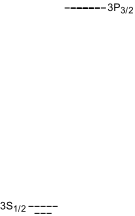

In [5]:
LGSSystem.diagram("NaD2_Repump", "ToScale")

Print some information about the system:

In [6]:
LGSSystem.info("NaD2_Repump")

#### Atomic levels

$\text{3S} _{1/2}$, $\text{3P} _{3/2}$

#### Pump transitions

1. $\text{3S} _{1/2}\land F=1\to \text{3P} _{3/2}$
1. $\text{3S} _{1/2}\land F=2\to \text{3P} _{3/2}$

#### Transition wavelengths

- $\text{3P} _{3/2}\to \text{3S} _{1/2}$: 589.158 nm

#### Substructure

- Hyperfine structure included
- Zeeman structure included
- 24 total sublevels

#### Density matrix elements

- All populations included
- All Zeeman coherences (between same level and same F) included
- All hyperfine coherences (between same level and different F) neglected
- Optical coherences (between different levels) included for pump transitions only
- 374 total density matrix elements

#### Input parameters

- BeamTransitRatePerS
- BFieldG
- MagneticAzimuthDegrees
- MagneticZenithDegrees
- RecoilParameter
- SDampingCollisionRatePerS
- TemperatureK
- VccRatePerS
- DetuningHz1
- DetuningHz2
- EllipticityDegrees1
- EllipticityDegrees2
- IntensitySI1
- IntensitySI2
- LaserWidthHz1
- LaserWidthHz2
- PolarizationAngleDegrees1
- PolarizationAngleDegrees2

Load the atomic system and set values for parameters that will not be varied:

In [7]:
lgs = LGSSystem(
    'NaD2_Repump', 
    {
        'EllipticityDegrees1': 45.,
        'PolarizationAngleDegrees1': 0,
        'DetuningHz1': 1.0832e9,
        'LaserWidthHz1': 10.0e6,
        'EllipticityDegrees2': 45.,
        'PolarizationAngleDegrees2': 0,
        'DetuningHz2': -6.268e8 + 1.e8,
        'LaserWidthHz2': 10.0e6,
        'MagneticZenithDegrees': 45.,
        'MagneticAzimuthDegrees': 45.,
        'SDampingCollisionRatePerS': 4081.63,
        'BeamTransitRatePerS': 131.944,
        'VccRatePerS': 28571.,
        'TemperatureK': 185.,
        'RecoilParameter': 1
    }
)

Define sample values for the varying parameters:

In [8]:
params = {'IntensitySI1': 5., 'IntensitySI2': 46., 'BFieldG': 0.5}

Build a steady-state model with adaptively refined velocity groups based on the sample parameters:

In [9]:
model = lgs.adaptive_stationary_model(params)

Solve the model for the steady state using the sample parameters:

In [10]:
sol = model.solve(params)

Find the total return flux:

In [11]:
model.total_flux(sol).item()

7709.055503256246

In [12]:
#| hide
test_close(_, 7709.0518, eps=1e-2)

Plot the return flux as a function of atomic velocity:

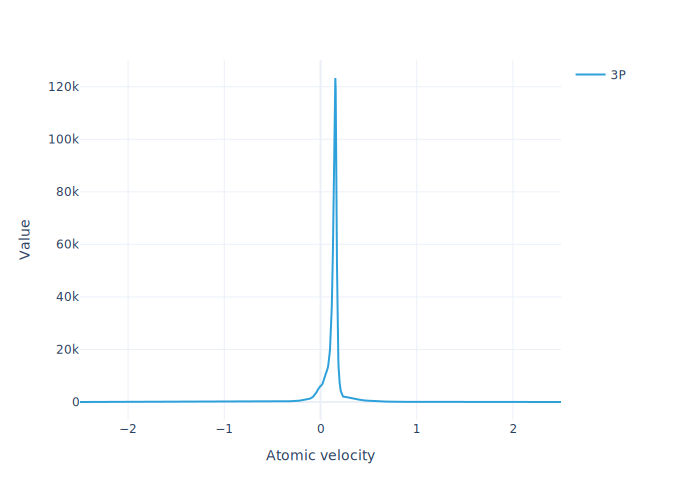

In [13]:
model.flux_distribution(sol).visualize()

Plot the ground and excited state populations as a function of atomic velocity:

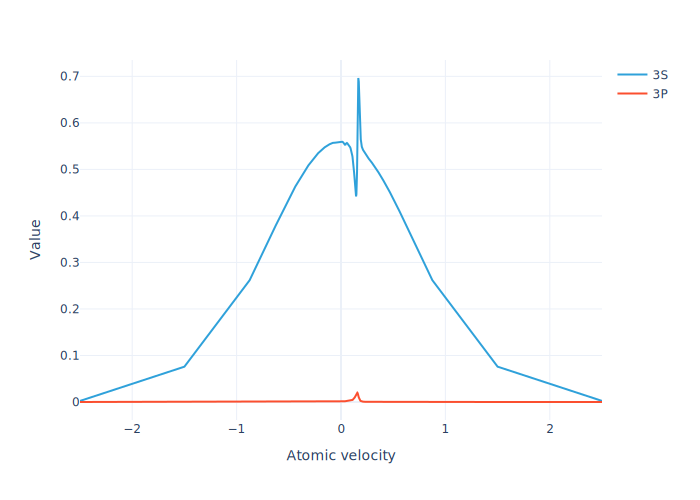

In [14]:
model.level_population_distribution(sol).visualize()

Plot the real and imaginary parts of all density-matrix elements:

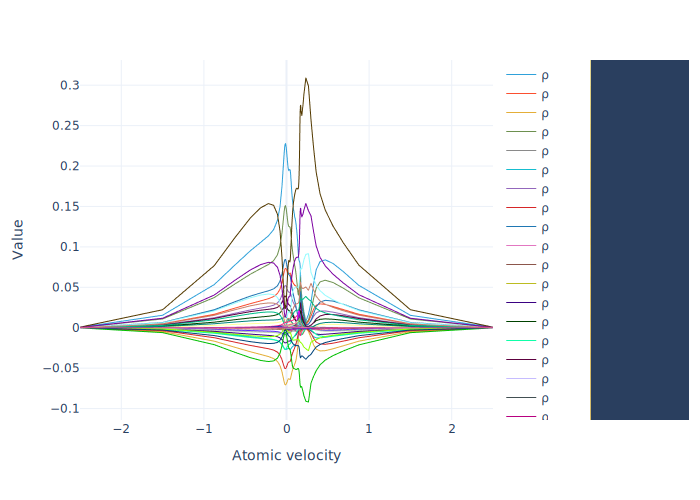

In [15]:
model.velocity_normalize(sol).visualize(line_width=1)

## LGS systems

The LGS system models are based on systems of equations generated using the [AtomicDensityMatrix](https://www.rochesterscientific.com/ADM/) package for Mathematica, together with an add-on package that has not yet been released, but will be available in the near future. If you are interested in modeling an LGS scheme that is not currently available as a built-in system, you can [create an issue](https://github.com/simonkeys/pylgs/issues/new) describing it and I will consider adding it as a built-in.

## Development

pyLGS is developed with the [nbdev](https://nbdev.fast.ai/) system for ["literate"](https://en.wikipedia.org/wiki/Literate_programming) programming^[or possibly ["semi-literate"](https://en.wikipedia.org/wiki/Literate_programming#Literate_programming_practices) programming] using Jupyter notebooks. The source code, documentation source, and tests are co-mingled in Jupyter notebooks (.ipynb files) contained in the `nbs` directory. The source code is exported to create the module (.py) files in the `pylgs` directory. Documentation is generated from the Jupyter notebooks using the [Quarto](https://quarto.org/) publishing system. Tests are run by batch evaluation of the notebooks.

## Copyright

Copyright © 2023 onward Simon Rochester (Rochester Scientific, LLC). Licensed under the GNU General Public License - Version 3 (the "License"); you may not use this project's files except in compliance with the License. A copy of the License is provided in the LICENSE file in this repository.